### Selecting Physical System and Run with Classical ODE Solve Method (20 pts)

Problem: Damped harmonic oscillator

Equation of motion is given by

$$
\begin{gather*}
m\ddot{x}=-kx-b\dot{x}\\
\ddot{x}+2\gamma\dot{x}+\omega^2x=0
\end{gather*}
$$
with $\omega_0^2=k/m$ and $\gamma=b/(2m)$. We can solve this problem using ansatz: $x(t)=e^{\lambda t}$. Therefore,
$$
\begin{align*}
(\lambda^2+2\gamma\lambda+\omega_0^2)x=0
\end{align*}
$$
The non trivial solution is given as
$$
\begin{gather*}
\lambda=-\gamma\pm\sqrt{\gamma^2-\omega_0^2}\\
\therefore x(t)=Ae^{(-\gamma+\sqrt{\gamma^2-\omega_0^2})t} + Be^{(-\gamma-\sqrt{\gamma^2-\omega_0^2})t}
\end{gather*}
$$
In this note, we treat only underdamped case, $\gamma^2<\omega_0^2$. Defining $\omega=\sqrt{\omega_0^2-\gamma^2}$, we have the general solution as
$$
\begin{align*}
x(t)=Ae^{(-\gamma+i\omega)t} + Be^{(-\gamma-i\omega)t}=e^{-\gamma t}(Ae^{i\omega t}+Be^{-i\omega t})=Ce^{-\gamma t}\cos(\omega t+\phi)
\end{align*}
$$
Here, $C$ and $\phi$ will be determined by initial conditions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# INITIAL CONDITIONS
x0 = 2.0 # Initial condition of x
v0 = 1.0 # Initial condition of v
w0 = 20.0 # \omega_0
g = 2.0 # \gamma
w = np.sqrt(w0**2 - g**2) # \omega=\sqrt{\omega_0^2-\gamma^2}

# ODE FUNCTION

def f(r, t, w0, g):
    r_new = np.zeros((r.shape[0]), dtype=float)
    r_new[0] = r[1]
    r_new[1] = -w0*w0*r[0] - 2*g*r[1]

    return r_new

In [2]:
# SELECTED CLASSICAL METHOD FOR SOLVING ODE: RK4

def RK4(f, r, t, h, w0=w0, g=g):
    k1 = h*f(r, t, w0, g)
    k2 = h*f(r + 0.5*k1, t + 0.5*h, w0, g)
    k3 = h*f(r + 0.5*k2, t + 0.5*h, w0, g)
    k4 = h*f(r + k3, t + h, w0, g)

    return r + (k1 + 2*k2 + 2*k3 + k4)/6.0

In [3]:
# SOLVE ODE
h = 0.01 # Time step
t = np.arange(0, 1, h) # Time
r = np.zeros((2, t.size), dtype=float)
# r[0] = x, position
# r[1] = v, velocity
r[0, 0] = x0
r[1, 0] = v0

for i, t_i in enumerate(range(t.size - 1)):
    r[:, i+1] = RK4(f, r[:, i], t_i, h)


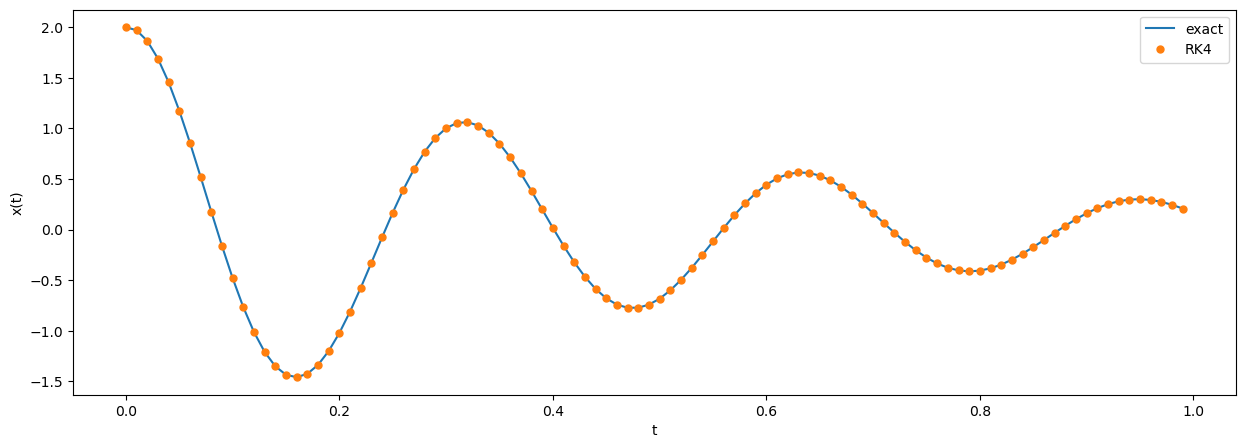

In [4]:
# VISUALIZATION
phi = np.arctan(-(g + v0/x0)/w)
C = x0/np.cos(phi)
x_exact = C*np.exp(-g*t)*np.cos(w*t + phi) # Exact solution

plt.figure(figsize=(15, 5))
plt.plot(t, x_exact, label="exact")
plt.plot(t, r[0], 'o', markersize=5, label="RK4")
#plt.plot(t, r[0], '--', label="RK4")
plt.xlabel("t")
plt.ylabel("x(t)")

plt.legend()
plt.show()

### Run with Simple NN (20pts)

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(1)

# SELECTED NEURAL NETWORK FOR SOLVING ODE

pinn_net = nn.Sequential(
    nn.Linear(1, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 1)
    )

In [6]:
# DEFINE RESIDUAL FUNCTION

def Residual(net, t_init, t_input, x0, v0, w0, g, r1=1e-1, r2=1e-3):
    '''
    net: neural newtork
    t_init: t for initial conidition
    t_input: t for propagation
    x0: Initial value of x
    v0: Inivial value of v
    w0, g: ODE parameters
    '''
    # loss for initial condition
    # dx/dt
    x_init = net(t_init)
    v0_pred = torch.autograd.grad(x_init, t_init, torch.ones_like(x_init), create_graph=True)[0]

    loss_init = (x_init.squeeze() - x0)**2 + r1*(v0_pred.squeeze() - v0)**2

    # loss for ODE
    # dx/dt
    x_pred = net(t_input)
    dx = torch.autograd.grad(x_pred, t_input, torch.ones_like(x_pred), create_graph=True)[0]
    #d^2x/dt^2
    ddx = torch.autograd.grad(dx, t_input, torch.ones_like(dx), create_graph=True)[0]

    loss_ode = r2*torch.mean((ddx + 2*g*dx + w0*w0*x_pred)**2)

    return loss_ode + loss_init

In [7]:
# DATASET GENERATION

t_init = torch.zeros([1, 1]).requires_grad_(True) # t for initial conidition
t_input = torch.linspace(0, 1, 30).view(-1, 1).requires_grad_(True) # t for propagation

Epoch 1000/15000, Loss: 3.9743990898132324
Epoch 2000/15000, Loss: 3.9710257053375244
Epoch 3000/15000, Loss: 3.3390090465545654
Epoch 4000/15000, Loss: 1.0832465887069702
Epoch 5000/15000, Loss: 0.7866047024726868
Epoch 6000/15000, Loss: 0.49857693910598755
Epoch 7000/15000, Loss: 0.45574477314949036
Epoch 8000/15000, Loss: 0.4226587116718292
Epoch 9000/15000, Loss: 0.38185083866119385
Epoch 10000/15000, Loss: 0.31934091448783875
Epoch 11000/15000, Loss: 0.18557046353816986
Epoch 12000/15000, Loss: 0.03899683058261871
Epoch 13000/15000, Loss: 0.029690910130739212
Epoch 14000/15000, Loss: 0.05031054466962814
Epoch 15000/15000, Loss: 0.015587017871439457


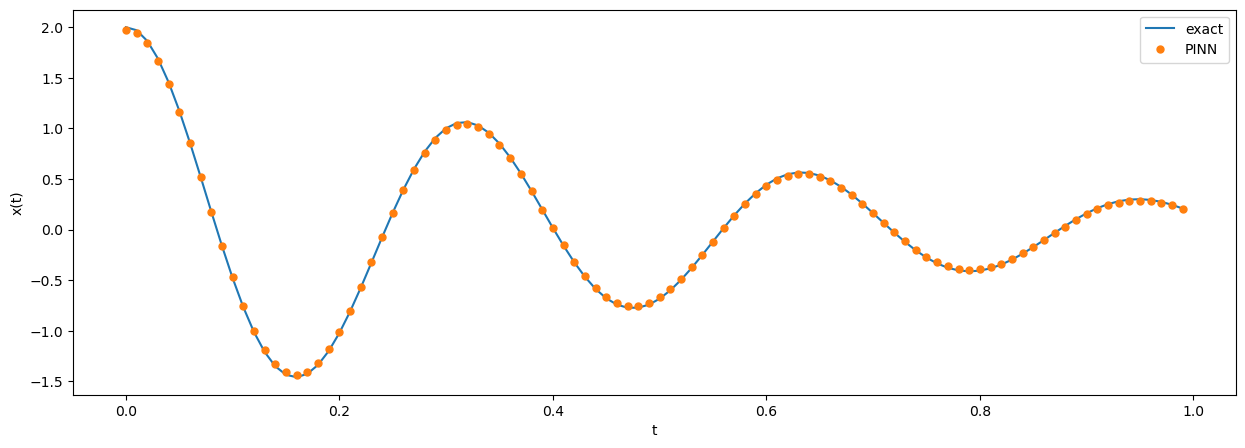

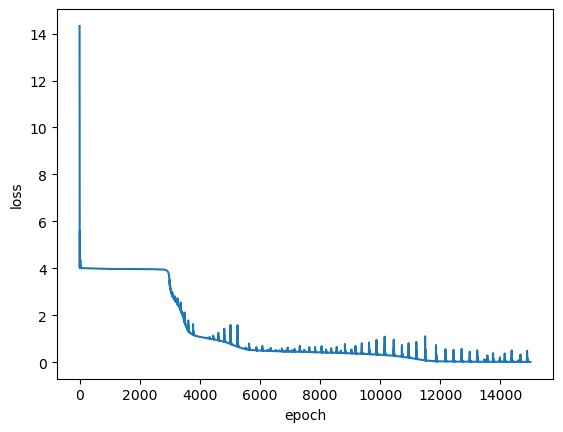

In [8]:
# TRAINING NEURAL NETWORK
epochs = 15000
loss_list = np.zeros(epochs, dtype=float)
optimizer = optim.Adam(pinn_net.parameters(), lr=1e-3)

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = Residual(pinn_net, t_init, t_input, x0, v0, w0, g)
    loss.backward()
    optimizer.step()
    loss_list[epoch] = loss.item()


    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")


with torch.no_grad():
    phi = np.arctan(-(g + v0/x0)/w)
    C = x0/np.cos(phi)
    x_exact = C*np.exp(-g*t)*np.cos(w*t + phi) # Exact solution

    x_pred = pinn_net(torch.tensor(t, dtype=torch.float32).view(-1,1))
    plt.figure(figsize=(15, 5))
    plt.plot(t, x_exact, label="exact")
    plt.plot(t, x_pred, 'o', markersize=5, label="PINN")
    plt.xlabel('t')
    plt.ylabel('x(t)')
    plt.legend()
    plt.show()

    plt.plot(loss_list)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

### Analysis Classical Method and Deep Learning Based Method (30pts)

YOUR SELECTED ANALYSIS METHOD (OR ANALYSIS PARAMETERS) EXPLANATION HERE (in markdown)

In [9]:
# ANALYSIS

# Classical method: RK4
# SOLVE ODE
h = 0.005 # Time step: 0.01 -> 0.005
t2 = np.arange(0, 1, h) # Time
r2 = np.zeros((2, t2.size), dtype=float)
# r[0] = x, position
# r[1] = v, velocity
r2[0, 0] = x0
r2[1, 0] = v0

for i, t_i in enumerate(range(t2.size - 1)):
    r2[:, i+1] = RK4(f, r2[:, i], t_i, h)

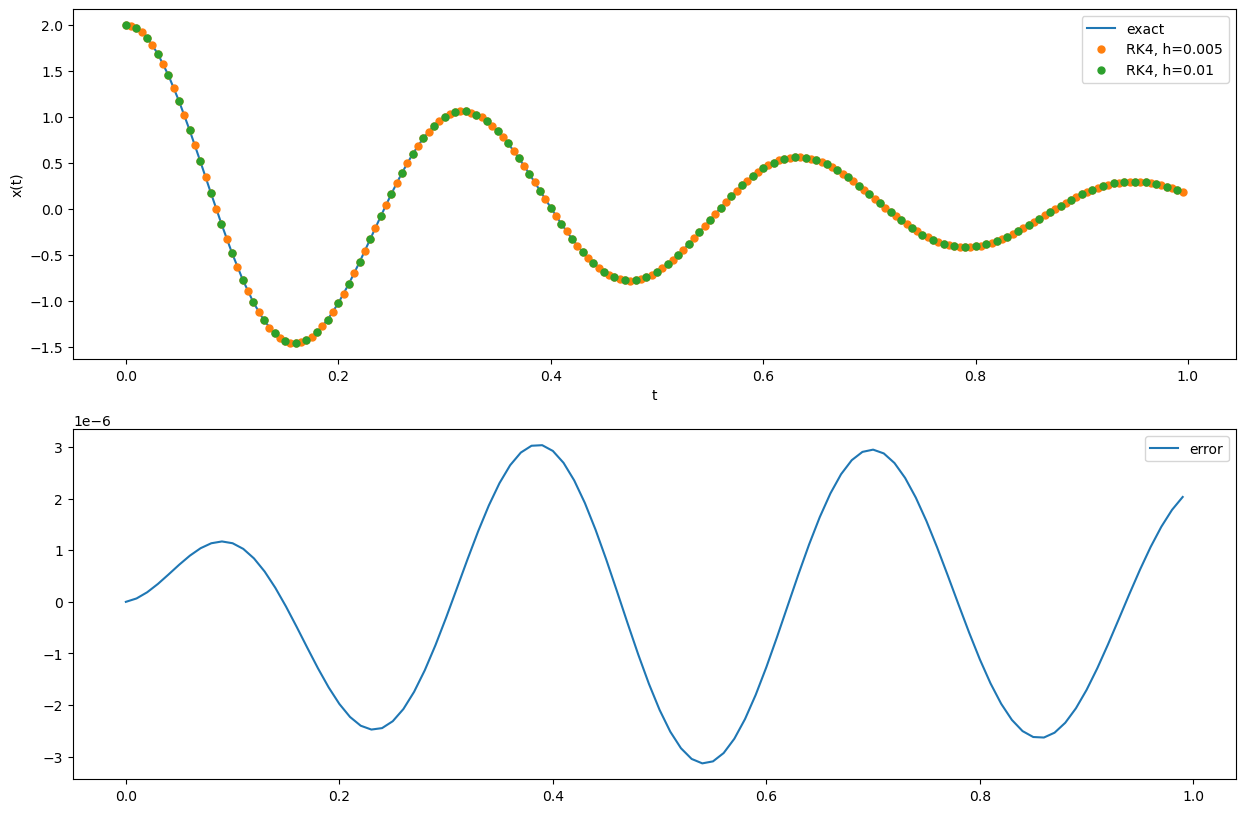

In [10]:
# VISUALIZATION
error = (r[0] - r2[0, ::2])/30

plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
plt.plot(t, x_exact, label="exact")
plt.plot(t2, r2[0], 'o', markersize=5, label="RK4, h=0.005")
plt.plot(t, r[0], 'o', markersize=5, label="RK4, h=0.01")
#plt.plot(t, r[0], '--', label="RK4")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()

plt.subplot(2,1,2)
plt.plot(t, error, label="error")

plt.legend()
plt.show()

Epoch 1000/35000, Loss: 4.086174488067627
Epoch 2000/35000, Loss: 4.0861334800720215
Epoch 3000/35000, Loss: 4.086112976074219
Epoch 4000/35000, Loss: 4.086083889007568
Epoch 5000/35000, Loss: 4.0860371589660645
Epoch 6000/35000, Loss: 4.0859880447387695
Epoch 7000/35000, Loss: 4.09183406829834
Epoch 8000/35000, Loss: 4.085856914520264
Epoch 9000/35000, Loss: 4.086014270782471
Epoch 10000/35000, Loss: 4.085578918457031
Epoch 11000/35000, Loss: 4.08524227142334
Epoch 12000/35000, Loss: 4.08474063873291
Epoch 13000/35000, Loss: 4.083681106567383
Epoch 14000/35000, Loss: 4.076897621154785
Epoch 15000/35000, Loss: 4.05277156829834
Epoch 16000/35000, Loss: 3.8897793292999268
Epoch 17000/35000, Loss: 3.7052807807922363
Epoch 18000/35000, Loss: 3.60821795463562
Epoch 19000/35000, Loss: 3.5105717182159424
Epoch 20000/35000, Loss: 3.4437363147735596
Epoch 21000/35000, Loss: 3.3832027912139893
Epoch 22000/35000, Loss: 3.305565595626831
Epoch 23000/35000, Loss: 3.229543685913086
Epoch 24000/35000

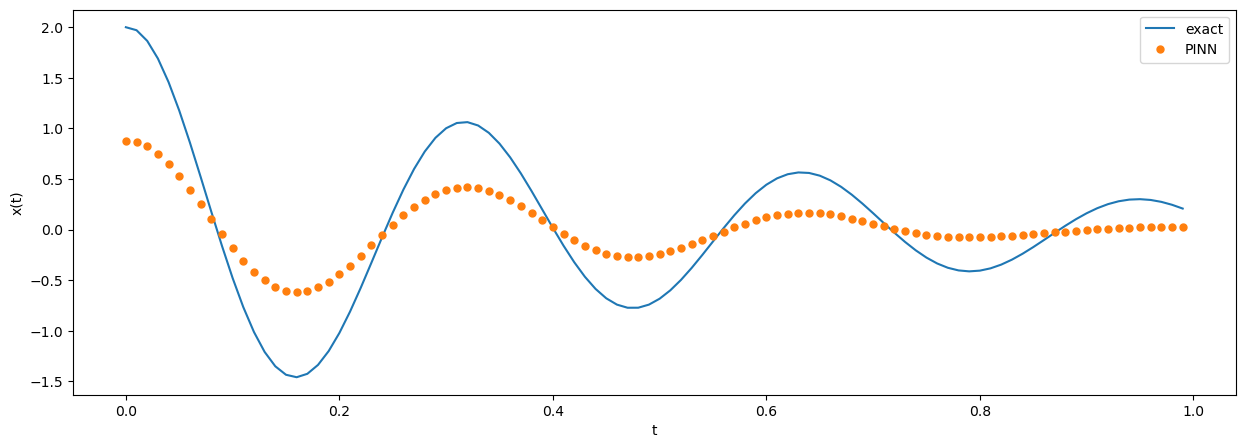

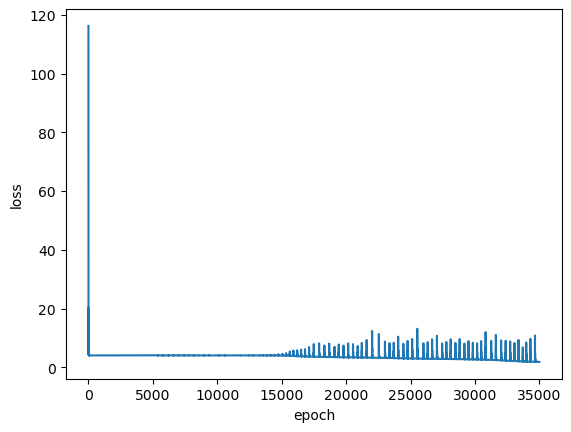

In [11]:
# ANALYSIS

# Deep learning based approach

torch.manual_seed(1)
pinn_net2 = nn.Sequential(
    # Activation function is changed to ReLU
    nn.Linear(1, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 1)
    )

# TRAINING NEURAL NETWORK
epochs = 35000
loss_list = np.zeros(epochs, dtype=float)
optimizer = optim.Adam(pinn_net2.parameters(), lr=1e-3)

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = Residual(pinn_net2, t_init, t_input, x0, v0, w0, g, r2=0.01)
    loss.backward()
    optimizer.step()
    loss_list[epoch] = loss.item()


    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")


with torch.no_grad():
    phi = np.arctan(-(g + v0/x0)/w)
    C = x0/np.cos(phi)
    x_exact = C*np.exp(-g*t)*np.cos(w*t + phi) # Exact solution

    x_pred = pinn_net2(torch.tensor(t, dtype=torch.float32).view(-1,1))
    plt.figure(figsize=(15, 5))
    plt.plot(t, x_exact, label="exact")
    plt.plot(t, x_pred, 'o', markersize=5, label="PINN")
    plt.xlabel('t')
    plt.ylabel('x(t)')
    plt.legend()
    plt.show()

    plt.plot(loss_list)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

Epoch 1000/35000, Loss: 3.9452083110809326
Epoch 2000/35000, Loss: 3.945204019546509
Epoch 3000/35000, Loss: 3.945202589035034
Epoch 4000/35000, Loss: 3.945202350616455
Epoch 5000/35000, Loss: 3.945202589035034
Epoch 6000/35000, Loss: 3.945202589035034
Epoch 7000/35000, Loss: 3.945542573928833
Epoch 8000/35000, Loss: 3.945202589035034
Epoch 9000/35000, Loss: 3.945202350616455
Epoch 10000/35000, Loss: 3.945202350616455
Epoch 11000/35000, Loss: 3.9452977180480957
Epoch 12000/35000, Loss: 3.945202589035034
Epoch 13000/35000, Loss: 3.945202350616455
Epoch 14000/35000, Loss: 3.945202112197876
Epoch 15000/35000, Loss: 3.945202589035034
Epoch 16000/35000, Loss: 3.945202350616455
Epoch 17000/35000, Loss: 3.945202589035034
Epoch 18000/35000, Loss: 3.9452028274536133
Epoch 19000/35000, Loss: 3.9452672004699707
Epoch 20000/35000, Loss: 3.945202350616455
Epoch 21000/35000, Loss: 3.945202350616455
Epoch 22000/35000, Loss: 3.945202589035034
Epoch 23000/35000, Loss: 3.945202350616455
Epoch 24000/3500

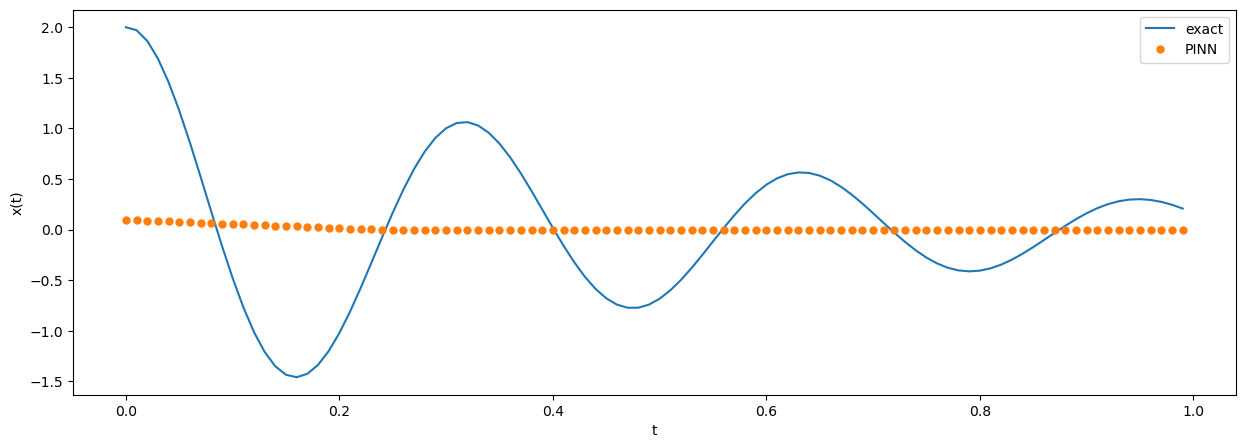

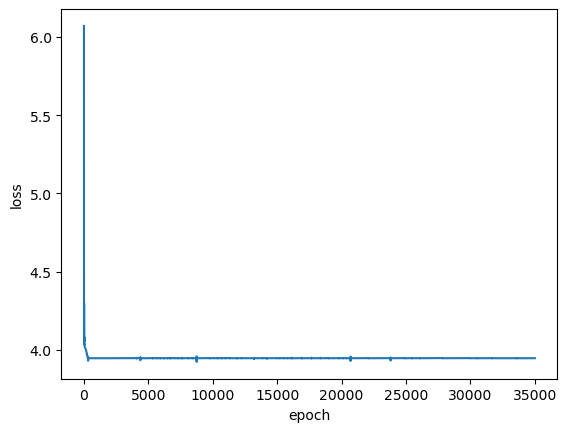

In [12]:
# ANALYSIS

# Deep learning based approach

torch.manual_seed(1)
pinn_net3 = nn.Sequential(
    # Activation function is changed to ReLU
    nn.Linear(1, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
    )

# TRAINING NEURAL NETWORK
epochs = 35000
loss_list = np.zeros(epochs, dtype=float)
optimizer = optim.Adam(pinn_net3.parameters(), lr=1e-3)

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = Residual(pinn_net3, t_init, t_input, x0, v0, w0, g)
    loss.backward()
    optimizer.step()
    loss_list[epoch] = loss.item()


    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")


with torch.no_grad():
    phi = np.arctan(-(g + v0/x0)/w)
    C = x0/np.cos(phi)
    x_exact = C*np.exp(-g*t)*np.cos(w*t + phi) # Exact solution

    x_pred = pinn_net3(torch.tensor(t, dtype=torch.float32).view(-1,1))
    plt.figure(figsize=(15, 5))
    plt.plot(t, x_exact, label="exact")
    plt.plot(t, x_pred, 'o', markersize=5, label="PINN")
    plt.xlabel('t')
    plt.ylabel('x(t)')
    plt.legend()
    plt.show()

    plt.plot(loss_list)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

## Discuss the results (30pts)
### Classical method
For the classical method, I used 4th order Runge-Kutta (RK4) method. First, I solved for $h=0.01$ and got solutio $x_1(t)$. Next, I changed step size to $h=0.005$ and got solution $x_2(t)$. Both of two solutions show good agreemet with exact solution. Also I estimated the error as $\epsilon=(x_1-x_2)/30$. The order of error was $\epsilon\sim10^{-6}$.
### Deep learning bases approach
For the deep learning based method, I defined the reidual function $L$ as
$$
\begin{gather*}
    L=(x_\theta(0)-x_0)^2+r_1(\dot{x}_\theta(0)-v_0)^2+r_2\frac{1}{N}\sum_{i=1}^N(\ddot{x}_\theta(t_i) +2\gamma\dot{x}_\theta(t_i)+\omega_0^2x_\theta(t_i))^2~.
\end{gather*}
$$
Here, $x_\theta(t)$ denotes the neural network's approximate solution, $\theta$ represents the network parameters and $r_1$, $r_2$ are the weights of the respective residual terms. In the deep learning experiments, the training performed better when the weight of the ODE residual ($r_2$) was smaller under the same conditions. For example, $r_1=0.1$ and $r_2=0.01$,even 35000 epochs were insufficient to get a good solution. However, with $r_1=0.1$ and $r_2=0.001$, approximate solution showed good agreement with the exact solution in only 15000 epochs. This phenomenon arises due to competition between the residual terms: if $r_2$ is too large, the neural network prioritizes firring the ODE at the expense of satisfying initial conditions.

I also tested the case where the activation function is ReLU. In this case, training was failed. This is due to the characteristic of ReLU function. The solution can be simply written as
$$
\begin{gather*}
    x_\theta(t)=\sigma(wt+b)
\end{gather*}
$$
Here, $w$ and $b$ are the parameters of neural network and $\sigma(x)=\text{ReLU}(x)$ is the activation function. If we calculate the derivatives,
$$
\begin{gather*}
    \frac{dx_\theta}{dt}=\begin{cases}w & (wx+b>0) \\ 0 & (wx+b<0) \end{cases}\\
    \frac{d^2x_\theta}{dt^2}=0\\
\end{gather*}
$$
Therefore, residual function for ODE cannot produce the correct value. We have to use smooth function such as $\tanh(x)$ or $\text{sigmoid}(x)$ as a activation function.